✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Apr-11 00:00 UTC F24 ┊ GRIB2 @ google ┊ IDX @ local


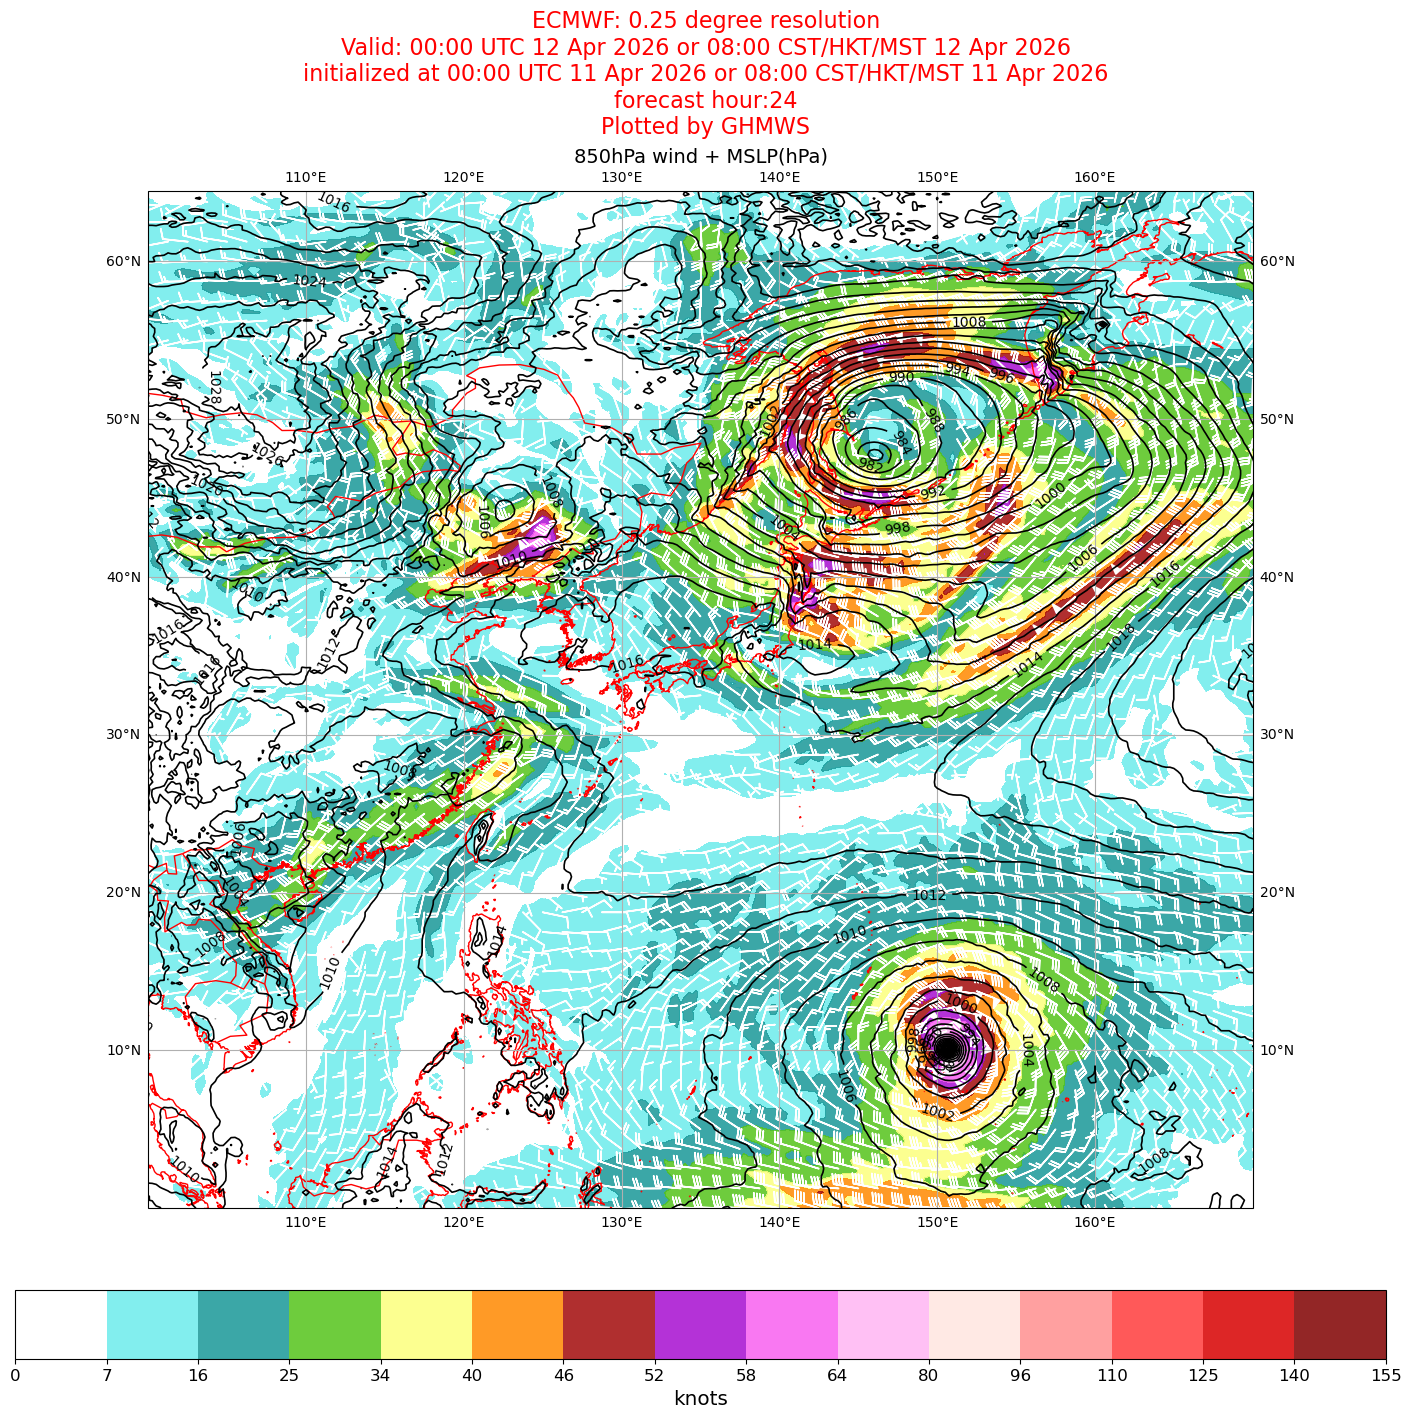

In [25]:
from herbie import Herbie

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np
import pandas as pd

from herbie import paint
from herbie.toolbox import EasyMap, pc
from scipy.interpolate import griddata
import scipy.ndimage
from PIL import Image
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

H = Herbie("2026-4-11-00", model="ifs", product="oper", fxx=24)

H.grib, H.idx

ds_2 = H.xarray(":u:850")
ds_3 = H.xarray(":v:850")
ds_4 = mpcalc.wind_speed(ds_2.u, ds_3.v)

ds_mslp = H.xarray(":msl:")

ds_2 = ds_2.sel(latitude=slice(90, 0,5), longitude=slice(90, 180,5))
ds_3 = ds_3.sel(latitude=slice(90, 0,5), longitude=slice(90, 180,5))
ds_4 = ds_4.sel(latitude=slice(90, 0), longitude=slice(90, 180))
ds_mslp = ds_mslp.sel(latitude=slice(90, 0), longitude=slice(90, 180))
mslp_hpa = ds_mslp.msl / 100

def plot_background(ax):
    ax.set_extent([100,170,0,60])
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1, edgecolor='red')
    ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='red')
    ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='red')
    gl = ax.gridlines(draw_labels=True)
    gl.xlabels_top = False
    gl.ylabels_left = False
    return ax

fig, ax = plt.subplots(figsize=(14, 14), constrained_layout=True,
                       subplot_kw={'projection': ccrs.PlateCarree()})
plot_background(ax)

gradient_colors = [
    "#FFFFFF", "#F0F0F0", "#E0E0E0", "#D0D0D0",
    "#80FFFF", "#70EFEF", "#60DFDF", "#50CFCF", "#40BFBF", "#30AFAF",
    "#209F9F", "#108F8F", "#007F7F",
    "#009966", "#20A946", "#40B92C", "#60C912",
    "#80D900", "#A0E920", "#C0F940", "#E0FF60",
    "#FFFF80", "#FFE960", "#FFD340", "#FFBD20", "#FFA700",
    "#FF9100", "#FF7B00", "#FF6500", "#FF4F00", "#FF3900",
    "#990000", "#A91010", "#B92020", "#C93030", "#D94040",
    "#9900CC", "#A910D2", "#B920D8", "#C930DE", "#D940E4",
    "#E950EA", "#F960F0", "#FF70F6", "#FF80FC",
    "#FF90FC", "#FFA0F8", "#FFB0F4", "#FFC0F0", "#FFD0EC",
    "#FFE0E8", "#FFF0E4", "#FFFFE0",
    "#FFE0E0", "#FFD0D0", "#FFC0C0", "#FFB0B0", "#FFA0A0",
    "#FF9090", "#FF8080", "#FF7070", "#FF6060", "#FF5050",
    "#FF4040", "#FF3030", "#FF2020", "#FF1010", "#FF0000",
    "#E00000", "#D00000", "#C00000", "#B00000", "#A00000",
    "#900000", "#800000"
]
cmap_custom = LinearSegmentedColormap.from_list("wind_smooth_original", gradient_colors, N=256)
custom_levels = [0,7,16,25,34,40,46,52,58,64,80,96,110,125,140,155]
norm_custom = BoundaryNorm(custom_levels, cmap_custom.N)

p = ax.contourf(
    ds_4.longitude,
    ds_4.latitude,
    ds_4*3.6/1.852,
    transform=pc,
    cmap=cmap_custom,
    norm=norm_custom,
    levels=custom_levels,
    alpha=0.85
)

mslp_levels = np.arange(800, 1100, 2)
cs = ax.contour(ds_mslp.longitude, ds_mslp.latitude, mslp_hpa,
                levels=mslp_levels, colors='black', linewidths=1.2,
                transform=pc)
ax.clabel(cs, inline=True, fontsize=10, fmt='%d')

u_kts = ds_2.u * 3.6 / 1.852
v_kts = ds_3.v * 3.6 / 1.852
ax.barbs(ds_2.longitude, ds_2.latitude, u_kts, v_kts,
         length=6, transform=pc, color='white', linewidth=1.2)

ax.set_title(f'850hPa wind + MSLP(hPa)', fontsize=14)

cb1 = fig.colorbar(p, ax=ax, orientation='horizontal')
cb1.set_label(f'knots', size='x-large')
cb1.set_ticks([0,7,16,25,34,40,46,52,58,64,80,96,110,125,140,155])
cb1.ax.tick_params(labelsize=12)

valid_UTC = ds_2.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()
valid_CST = (pd.to_datetime(ds_2.valid_time.values) + pd.Timedelta(hours=8)).strftime('%H:%M CST/HKT/MST %d %b %Y')
init_UTC = ds_2.time.dt.strftime('%H:%M UTC %d %b %Y').item()
init_CST = (pd.to_datetime(ds_2.time.values) + pd.Timedelta(hours=8)).strftime('%H:%M CST/HKT/MST %d %b %Y')

fig.suptitle(
    f"ECMWF: 0.25 degree resolution\nValid: {valid_UTC} or {valid_CST}\ninitialized at {init_UTC} or {init_CST}\nforecast hour:{H.fxx}\nPlotted by GHMWS",
    color='red', fontsize=16
)

plt.show()